# Airline Customer Satisfaction Prediction

This project aims to analyze customer satisfaction in the airline industry by exploring a dataset that includes demographic information, travel characteristics, and service quality indicators. The analysis begins with data preparation and exploratory data analysis in order to understand the structure of the dataset and identify relevant patterns. Special focus is given to variables related to service experience, such as comfort, cleanliness, and onboard services, as these are expected to strongly influence customer satisfaction.

The project then applies a range of predictive modelling techniques to estimate the target variable. Principal Component Analysis is used to reduce dimensionality and uncover underlying relationships between variables. Several classification models are developed and compared, including Decision Trees, Bagging, Random Forest, XGBoost, and Neural Networks. The goal is to evaluate model performance while also considering interpretability, and to determine which approach provides the most effective prediction of customer satisfaction.

# Table of Contents

In [ ]:
# Create table of contents using a dictionary

table_of_contents = {
    "Introduction": None,
    "1. Data Preparation and Processing": {
        "1.1. Exploratory Data Analysis": None
    },
    "2. PCA": {
        "2.1. PCA Requirements": {
            "2.1.1. Standardized Variables": None,
            "2.1.2. Multicollinearity": None
        },
        "2.2. Applying PCA and Choosing the Number of Components": None,
        "2.3. Analysing the Components": {
            "Components": None
        }
    },
    "3. Training and Test Dataset Split": {
        "3.1. Transformation of Non-Numeric Variables": None,
        "3.2. Training and Test Dataset Split": None
    },
    "4. Predictive Modelling": {
        "4.1. Decision Tree": {
            "4.1.1. Baseline": None,
            "4.1.2. PCA": None
        },
        "4.2. Results Optimization": {
            "4.2.1. Bagging Model": None,
            "4.2.2. XGBClassifier": None
        },
        "4.3. Gridsearch": {
            "4.3.1. GridSearchCV - Decision Tree": {
                "4.3.1.1. Baseline": None,
                "4.3.1.2. PCA": None
            },
            "4.3.2. GridSearchCV - Bagging": None,
            "4.3.3. GridSearchCV - Gradient Boosting": None,
            "4.3.4. GridSearchCV - XGBClassifier": None,
            "4.3.5. GridSearchCV - Random Forest": None
        },
        "4.4. Neural Network": {
            "4.4.1. Baseline": None,
            "4.4.2. Tuning": None
        }
    },
    "5. Results": None
}

# Function to display the table of contents
def display_table_of_contents(table_of_contents, level=0):
    for key, value in table_of_contents.items():
        print("\t" * level + f"{key}")
        if isinstance(value, dict):
            display_table_of_contents(value, level + 1)

# Display the table of contents
display_table_of_contents(table_of_contents)

Introduction
1. Data Preparation and Processing
	1.1. Exploratory Data Analysis
2. PCA
	2.1. PCA Requirements
		2.1.1. Standardized Variables
		2.1.2. Multicollinearity
	2.2. Applying PCA and Choosing the Number of Components
	2.3. Analysing the Components
		Components
3. Training and Test Dataset Split
	3.1. Transformation of Non-Numeric Variables
	3.2. Training and Test Dataset Split
4. Predictive Modelling
	4.1. Decision Tree
		4.1.1. Baseline
		4.1.2. PCA
	4.2. Results Optimization
		4.2.1. Bagging Model
		4.2.2. XGBClassifier
	4.3. Gridsearch
		4.3.1. GridSearchCV - Decision Tree
			4.3.1.1. Baseline
			4.3.1.2. PCA
		4.3.2. GridSearchCV - Bagging
		4.3.3. GridSearchCV - Gradient Boosting
		4.3.4. GridSearchCV - XGBClassifier
		4.3.5. GridSearchCV - Random Forest
	4.4. Neural Network
		4.4.1. Baseline
		4.4.2. Tuning
5. Results


# Introduction

# 1.   Data Preparation and Processing

In [ ]:
pip install factor_analyzer

In [ ]:
# =========================================
# Import Required Libraries
# =========================================


# Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Factor Analysis and Dimensionality Reduction
from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity,
    calculate_kmo
)
from sklearn.decomposition import PCA
# Data Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
# Model Selection and Validation
from sklearn.model_selection import (
    KFold,
    train_test_split,
    GridSearchCV
)
# Classification Models
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
# Pipelines
from sklearn.pipeline import Pipeline
# Evaluation Metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
import shap
import pandas as pd
import numpy as np

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Read the airplane dataset, creating a dataframe assigned to the variable "df"
df = pd.read_csv("Invistico_Airline.csv")
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [ ]:
# View dataset general info (Type of Variables)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [ ]:
# View the number of rows and columns in the dataframe
df.shape

(129880, 23)

The dataset consists of 23 variables and 129,880 observations.

In [ ]:
# Check whether there are any null values in the dataframe
have_nulls = df.isnull().any()
print(have_nulls)

satisfaction                         False
Gender                               False
Customer Type                        False
Age                                  False
Type of Travel                       False
Class                                False
Flight Distance                      False
Seat comfort                         False
Departure/Arrival time convenient    False
Food and drink                       False
Gate location                        False
Inflight wifi service                False
Inflight entertainment               False
Online support                       False
Ease of Online booking               False
On-board service                     False
Leg room service                     False
Baggage handling                     False
Checkin service                      False
Cleanliness                          False
Online boarding                      False
Departure Delay in Minutes           False
Arrival Delay in Minutes              True
dtype: bool

One of the requirements for both PCA and logistic regression is the absence of missing values.

In [ ]:
# Check the number of missing values
num_nulls = df["Arrival Delay in Minutes"].isnull().sum()
print(num_nulls)

393


The missing values in the variable "Arrival Delay in Minutes" represent 0.14% of the dataset.

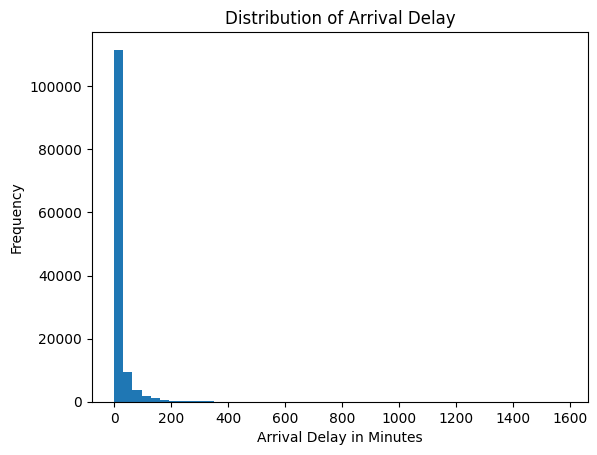

Mean: 15.09112883918849
Median: 0.0


In [ ]:
# Distribution of Arrival Delay
plt.figure()
plt.hist(df["Arrival Delay in Minutes"], bins=50)
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

# Check measures of central tendency: mean and median
mean_arrival_delay = df["Arrival Delay in Minutes"].mean()
median_arrival_delay = df["Arrival Delay in Minutes"].median()
print("Mean:", mean_arrival_delay)
print("Median:", median_arrival_delay)

Considering that "Arrival Delay in Minutes" does not follow a normal distribution, the most appropriate approach to handle missing values is to replace them with the median, which is 0 minutes. This indicates that at least 50% of the flights experienced no arrival delay, making it a representative and robust value for imputing the 0.14% of missing data.

In [ ]:
# Replacing missing values with the median
df["Arrival Delay in Minutes"].fillna(df["Arrival Delay in Minutes"].median(),inplace=True)

/tmp/ipykernel_18798/1187324549.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Arrival Delay in Minutes"].fillna(df["Arrival Delay in Minutes"].median(),inplace=True)


In [ ]:
# Check if there are still any null values in the dataframe
have_nulls = df.isnull().any()
print(have_nulls)

satisfaction                         False
Gender                               False
Customer Type                        False
Age                                  False
Type of Travel                       False
Class                                False
Flight Distance                      False
Seat comfort                         False
Departure/Arrival time convenient    False
Food and drink                       False
Gate location                        False
Inflight wifi service                False
Inflight entertainment               False
Online support                       False
Ease of Online booking               False
On-board service                     False
Leg room service                     False
Baggage handling                     False
Checkin service                      False
Cleanliness                          False
Online boarding                      False
Departure Delay in Minutes           False
Arrival Delay in Minutes             False
dtype: bool

# 1.1. Exploratory Data Analysis

In [ ]:
columns  = ["Seat comfort","Departure/Arrival time convenient","Food and drink","Gate location","Inflight wifi service","Inflight entertainment","Online support","Ease of Online booking","On-board service","Leg room service","Baggage handling","Checkin service","Cleanliness","Online boarding"]

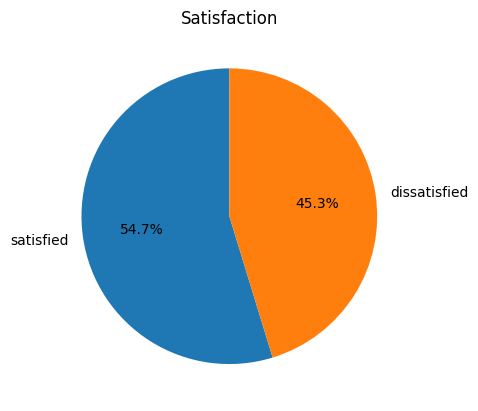

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64


In [ ]:
# Satisfaction - Pie chart
satisfaction_counts = df["satisfaction"].value_counts()
plt.figure()
plt.pie(satisfaction_counts, labels=satisfaction_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Satisfaction")
plt.show()
# Satisfaction - Count
print(df["satisfaction"].value_counts())

The target variable shows a relatively balanced distribution, with approximately 54% satisfied and 45% dissatisfied customers. Therefore, there is no need to apply balancing techniques such as oversampling or undersampling.

In [ ]:
# Cross table: Percentage of Gender vs Satisfaction
gender_satisfaction_percentage = pd.crosstab(
    df["Gender"],
    df["satisfaction"],
    normalize="index"
) * 100

print(gender_satisfaction_percentage)

satisfaction  dissatisfied  satisfied
Gender                               
Female           34.857889  65.142111
Male             55.988497  44.011503


When crossing the satisfaction variable with gender, it can be observed that there is a higher tendency for women in this dataset to be satisfied with the service, with 65% of female users satisfied. In contrast, the male group shows a greater tendency toward dissatisfaction, although it remains relatively balanced (56% vs 44%).

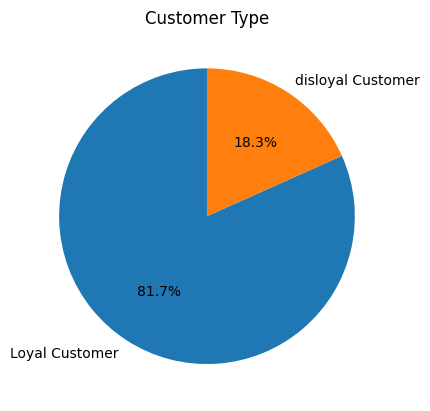

Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64


In [ ]:
# Customer Type - Pie chart
customer_type_counts = df["Customer Type"].value_counts()
plt.figure()
plt.pie(customer_type_counts, labels=customer_type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Customer Type")
plt.show()
# Customer Type - Count
print(df["Customer Type"].value_counts())

In [ ]:
# Cross table: Percentage of Customer Type vs Satisfaction
customer_satisfaction_percentage = pd.crosstab(
    df["Customer Type"],
    df["satisfaction"],
    normalize="index"
) * 100
print(customer_satisfaction_percentage)

satisfaction       dissatisfied  satisfied
Customer Type                             
Loyal Customer        38.372290  61.627710
disloyal Customer     76.030278  23.969722


As expected, the majority of loyal customers tend to be satisfied with the service, with only 38% of users not being satisfied, while 76% of disloyal customers were dissatisfied. This may indicate that the variable "Customer Type" could play an important role in explaining the target variable.

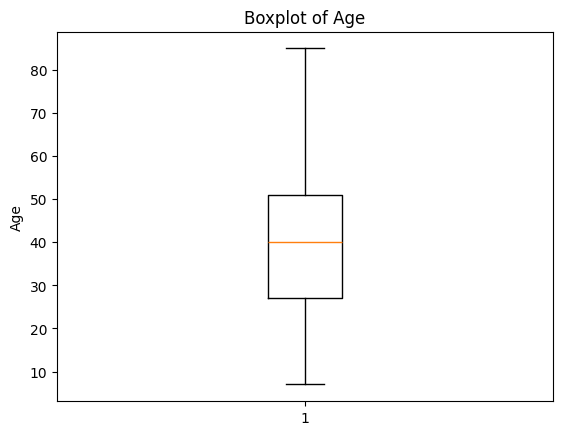

In [ ]:
# Age - Boxplot
plt.figure()
plt.boxplot(df["Age"])
plt.ylabel("Age")
plt.title("Boxplot of Age")
plt.show()

Approximately 50% of the ages are concentrated between 30 and 50 years, with half of these observations further concentrated between 40 and 50 years, indicating a higher density of individuals in this upper age range.

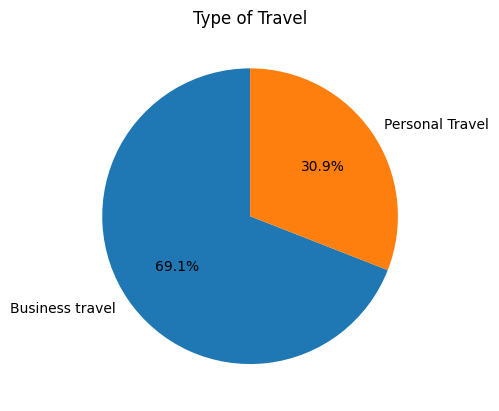

Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64


In [ ]:
# Type of Travel - Pie chart
travel_type_counts = df["Type of Travel"].value_counts()
plt.figure()
plt.pie(travel_type_counts, labels=travel_type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Type of Travel")
plt.show()
# Type of Travel - Count
print(df["Type of Travel"].value_counts())

In [ ]:
# Cross table: Satisfaction vs Type of Travel (column percentages)
satisfaction_travel_percentage = pd.crosstab(
    df["satisfaction"],
    df["Type of Travel"],
    normalize="columns"
) * 100

print(satisfaction_travel_percentage)

Type of Travel  Business travel  Personal Travel
satisfaction                                    
dissatisfied          41.627552          53.3904
satisfied             58.372448          46.6096


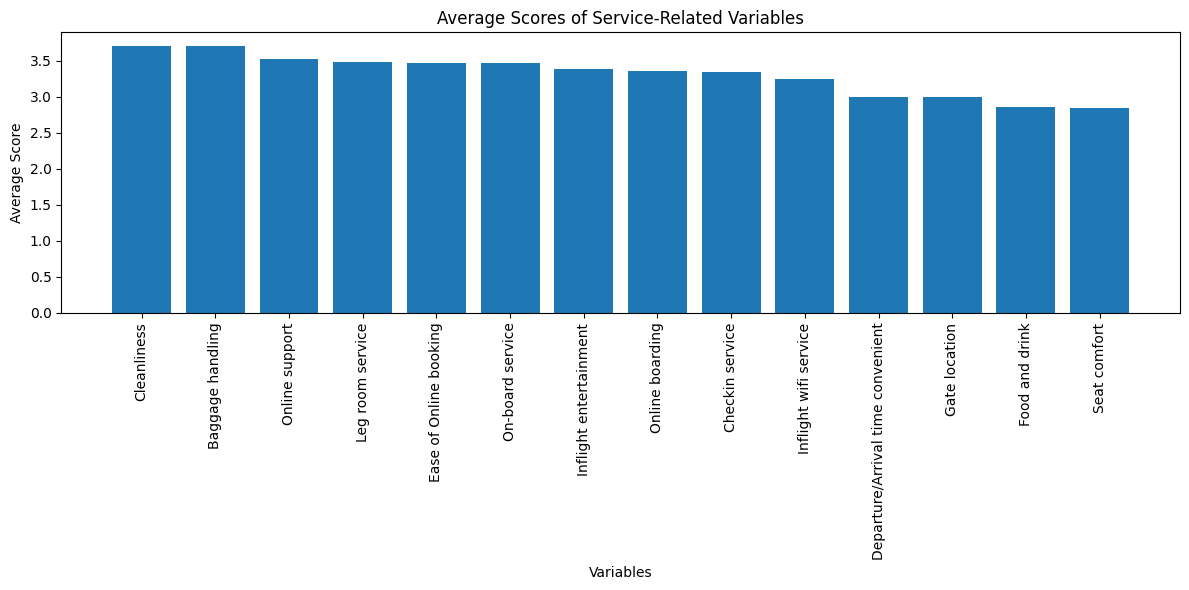

In [ ]:
# Service rating columns - Bar chart in the same image
mean_scores = df[columns].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(mean_scores.index, mean_scores.values)
plt.xticks(rotation=90)
plt.xlabel("Variables")
plt.ylabel("Average Score")
plt.title("Average Scores of Service-Related Variables")
plt.tight_layout()
plt.show()

The average ratings range between 3.0 and 3.5 across the different service dimensions. Cleanliness and Baggage Handling present the highest average scores, indicating stronger performance in these areas. In contrast, Food and Drink and Seat Comfort exhibit the lowest averages, suggesting relatively weaker customer satisfaction in these aspects.

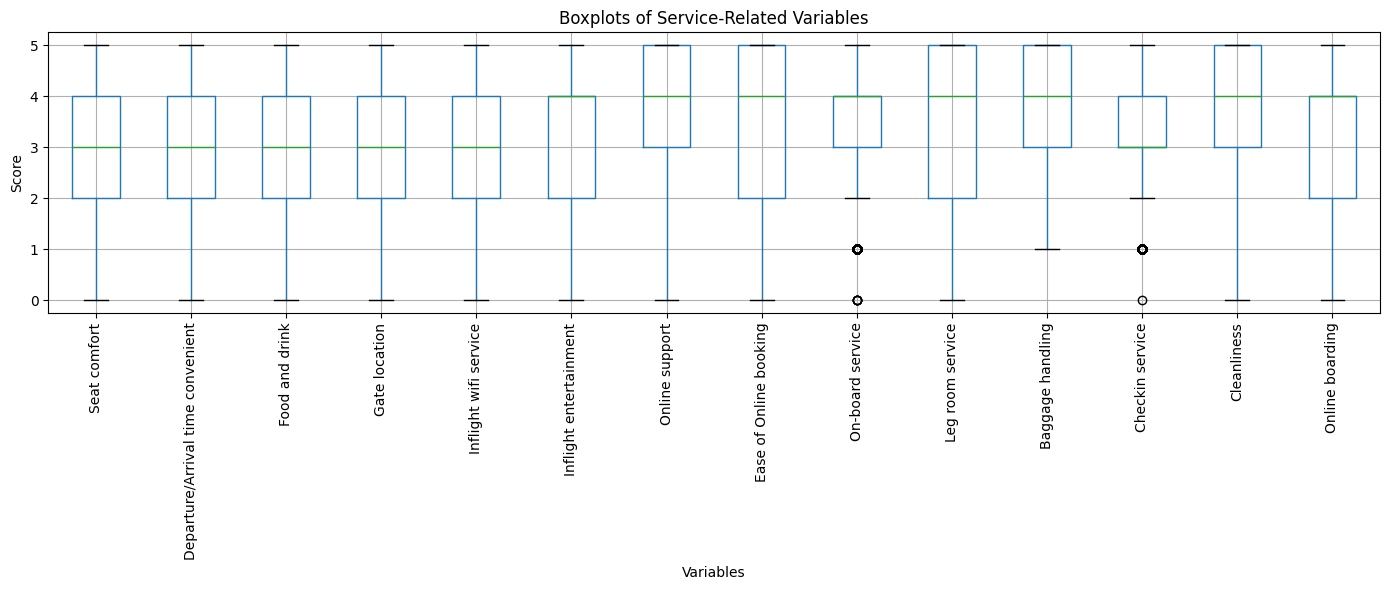

In [ ]:
# Service rating columns - Boxplots in the same image
plt.figure(figsize=(14, 6))
df[columns].boxplot()
plt.xticks(rotation=90)
plt.xlabel("Variables")
plt.ylabel("Score")
plt.title("Boxplots of Service-Related Variables")
plt.tight_layout()
plt.show()

Approximately 75% of users rated both Online Support and Cleanliness between 3 and 5, indicating generally positive perceptions of these services.

For On-board service and Check-in service, nearly 100% of users assigned ratings between 2 and 5, with a strong concentration in the higher categories: around 50% of the ratings fall between 4 and 5, and an additional 25% are also clustered in the upper range, reinforcing the overall positive evaluation of these services.

Across most service-related variables, 50% of the ratings are concentrated between 2 and 4, suggesting moderate satisfaction levels with some variability in user experience.

Finally, Ease of Online Booking stands out, with 50% of the ratings between 4 and 5, and an additional 25% between 3 and 4, highlighting a relatively strong performance compared to other service dimensions.

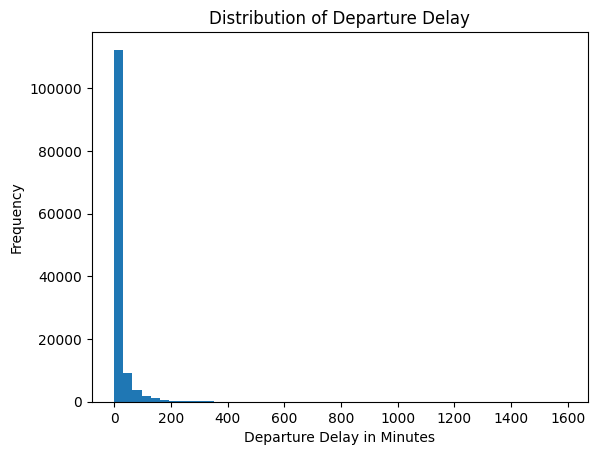

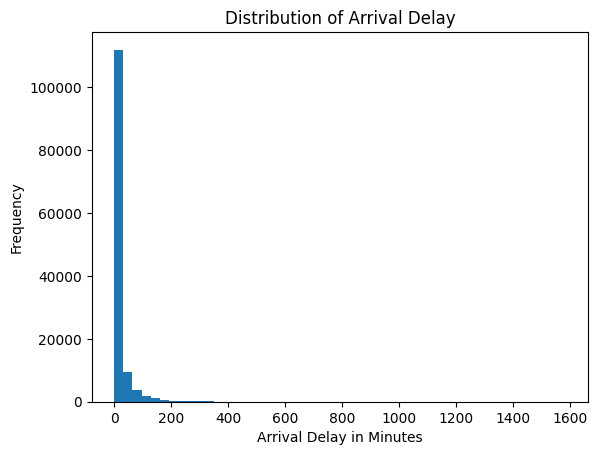

In [ ]:
# Departure Delay in Minutes - Histogram
plt.figure()
plt.hist(df["Departure Delay in Minutes"], bins=50)
plt.xlabel("Departure Delay in Minutes")
plt.ylabel("Frequency")
plt.title("Distribution of Departure Delay")
plt.show()
# Arrival Delay in Minutes - Histogram
plt.figure()
plt.hist(df["Arrival Delay in Minutes"], bins=50)
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

O Arrival Delay e o Departure Delay seguem distribuição semelhantes

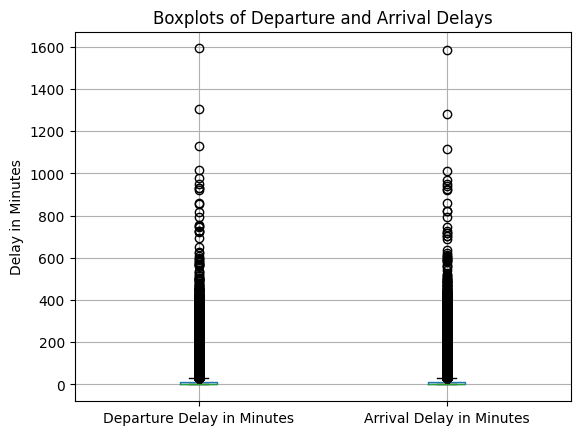

In [ ]:
# Boxplots for Departure and Arrival Delay in the same figure
delay_columns = [
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]
plt.figure()
df[delay_columns].boxplot()
plt.ylabel("Delay in Minutes")
plt.title("Boxplots of Departure and Arrival Delays")
plt.show()

Outliers will need to be carefully considered in the logistic regression model. Their usefulness will depend on whether they help identify meaningful patterns in the data or whether they introduce distortions in the model estimates. If they represent valid observations, they may provide relevant information and should be retained. However, if they exert excessive influence on the model or result from data errors, they may need to be treated or excluded at a later stage.

For the exploratory analysis, we will examine whether delay time is in any way related to customer satisfaction. To do so, these variables will be transformed into categorical variables and cross-tabulated with the customer satisfaction variable.

For this purpose, 30-minute intervals will be created in order to assess whether there is a growing tendency toward dissatisfaction as delays increase. Based on the histograms and boxplots, values above 3 hours (180 minutes) can be reasonably considered outliers.

In [ ]:
# Create categorical variables for delays in 30-minute intervals up to 180 minutes
df["Departure Delay Category"] = pd.cut(
    df["Departure Delay in Minutes"],
    bins=[-1, 30, 60, 90, 120, 150, 180, float("inf")],
    labels=["0-30", "31-60", "61-90", "91-120", "121-150", "151-180", "Outlier (>180)"]
)
df["Arrival Delay Category"] = pd.cut(
    df["Arrival Delay in Minutes"],
    bins=[-1, 30, 60, 90, 120, 150, 180, float("inf")],
    labels=["0-30", "31-60", "61-90", "91-120", "121-150", "151-180", "Outlier (>180)"]
)

In [ ]:
# Departure Delay Category vs Satisfaction (row percentages)
departure_delay_satisfaction_percentage = pd.crosstab(
    df["Departure Delay Category"],
    df["satisfaction"],
    normalize="index"
) * 100
print(departure_delay_satisfaction_percentage.round(2))

satisfaction              dissatisfied  satisfied
Departure Delay Category                         
0-30                             43.90      56.10
31-60                            51.13      48.87
61-90                            52.53      47.47
91-120                           53.19      46.81
121-150                          61.09      38.91
151-180                          64.44      35.56
Outlier (>180)                   64.11      35.89


In [ ]:
# Arrival Delay Category vs Satisfaction (row percentages)
arrival_delay_satisfaction_percentage = pd.crosstab(
    df["Arrival Delay Category"],
    df["satisfaction"],
    normalize="index"
) * 100
print(arrival_delay_satisfaction_percentage.round(2))

satisfaction            dissatisfied  satisfied
Arrival Delay Category                         
0-30                           43.84      56.16
31-60                          51.76      48.24
61-90                          52.62      47.38
91-120                         52.02      47.98
121-150                        60.54      39.46
151-180                        66.44      33.56
Outlier (>180)                 63.55      36.45


A general downward trend in customer satisfaction can be observed, suggesting that both delay variables may influence satisfaction.

The only exception occurs in the transition from the 151–180 minute interval to the outlier category, where the percentage of satisfied customers increases slightly for arrival delay. This variation may be explained by the smaller number of observations in these categories, which reduces the reliability and stability of the observed trend.

# 2. PCA

## 2.1 PCA requirements

### 2.1.1 Standardized Variables

The variables selected for the PCA are all measured on the same scale (ranging from 0 to 5), therefore there is no need to standardize the data prior to the analysis.


### 2.1.2 Multicollinearity

PCA requires the presence of some degree of multicollinearity (i.e., correlations) among the variables included in the analysis.

This requirement can be assessed through:

* the inspection of the correlation matrix,
* the Kaiser-Meyer-Olkin (KMO) measure of sampling adequacy,
* and Bartlett’s Test of Sphericity, which evaluates whether the correlation matrix significantly differs from an identity matrix.

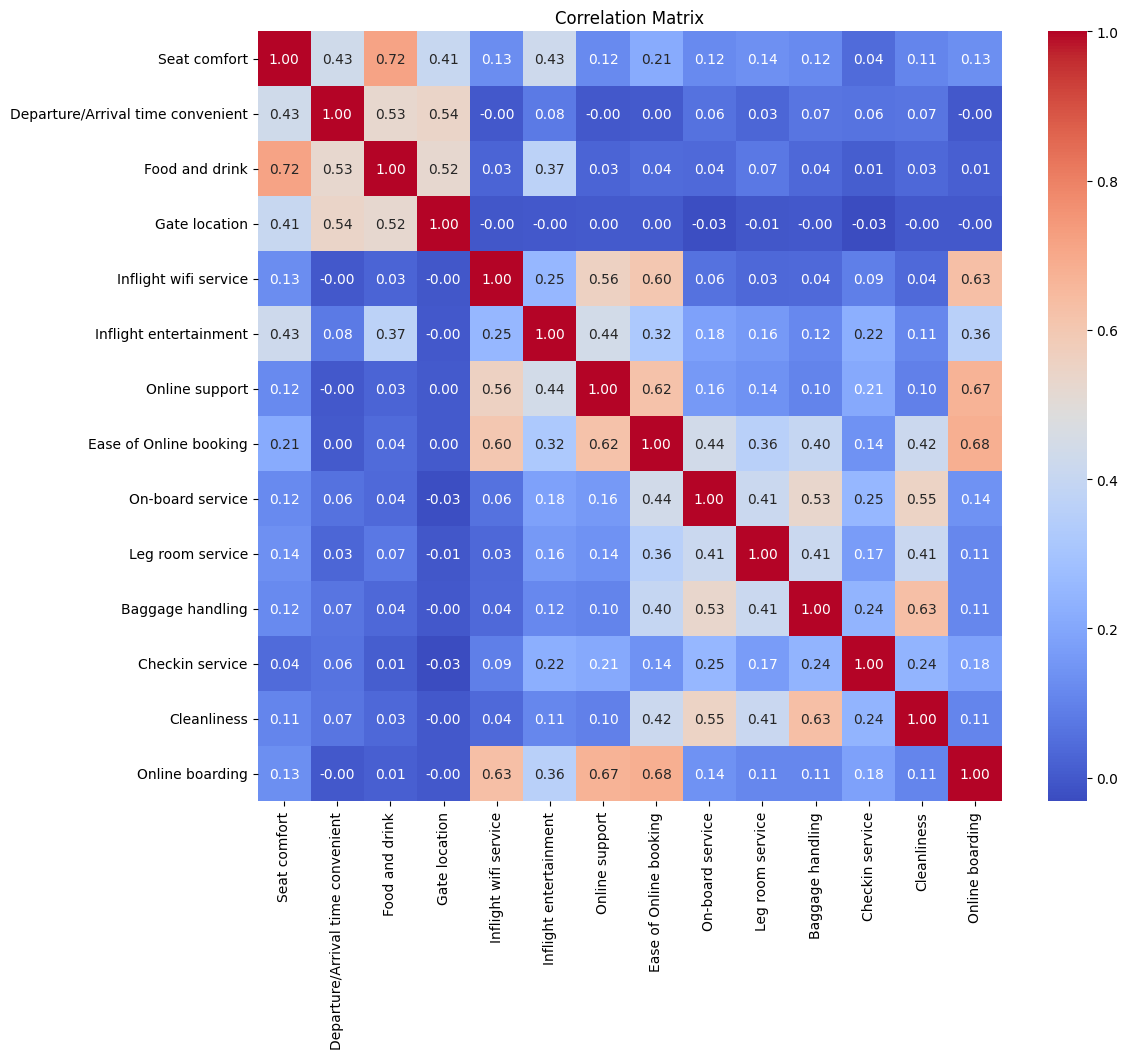

In [ ]:
# Correlation Matrix
corr_matrix = df[columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that most of the relationships between variables are relatively low.

In general:

*Most correlations fall within the range of 0.00 to 0.30, suggesting weak relationships.
*A smaller number of correlations lie between 0.30 and 0.50, indicating moderate associations.
*Only a few variable pairs exhibit stronger correlations above 0.50.

Notable higher correlations include:

* Seat comfort and Food and drink (0.72)
* Online boarding with Ease of Online booking (0.68) and Online support (0.67)
* Cleanliness and Baggage handling (0.63)

These stronger relationships suggest that certain groups of services—particularly those related to online experience and on-board comfort—tend to be perceived similarly by customers.

In [ ]:
#  Bartlett's Test of Sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(df[columns])

print("Bartlett's Test of Sphericity")
print("Chi-square value:", chi_square_value)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0. The variables are sufficiently correlated, so PCA may be appropriate.")
else:
    print("Result: Fail to reject H0. PCA may not be appropriate.")

Bartlett's Test of Sphericity
Chi-square value: 785741.7304551387
P-value: 0.0
Result: Reject H0. The variables are sufficiently correlated, so PCA may be appropriate.


Result: Reject H0. The variables are sufficiently correlated, so PCA may be appropriate.

In [ ]:
# Kaiser-Meyer-Olkin (KMO) Test
kmo_per_variable, kmo_model = calculate_kmo(df[columns])

print("KMO for each variable:")
print(dict(zip(columns, kmo_per_variable)))

print("\nOverall KMO:")
print(kmo_model)

KMO for each variable:
{'Seat comfort': np.float64(0.7644657705564502), 'Departure/Arrival time convenient': np.float64(0.7897170981603794), 'Food and drink': np.float64(0.7141103351670974), 'Gate location': np.float64(0.7358367974020129), 'Inflight wifi service': np.float64(0.840308842476642), 'Inflight entertainment': np.float64(0.7481229098612359), 'Online support': np.float64(0.8348844434025465), 'Ease of Online booking': np.float64(0.7746328619821728), 'On-board service': np.float64(0.8478629708183513), 'Leg room service': np.float64(0.8895253586271308), 'Baggage handling': np.float64(0.8247812264700598), 'Checkin service': np.float64(0.7337618734354536), 'Cleanliness': np.float64(0.8029951260521248), 'Online boarding': np.float64(0.8237761379227405)}

Overall KMO:
0.794700640568118


The Kaiser-Meyer-Olkin (KMO) measure was used to assess the sampling adequacy for each variable and for the overall dataset.

The overall KMO value of 0.7947 indicates a good level of sampling adequacy, suggesting that the dataset is suitable for Principal Component Analysis (PCA).

At the individual level, all variables present KMO values above 0.7, which is generally considered acceptable. Several variables, such as Leg room service (0.8895), On-board service (0.8479), and Inflight wifi service (0.8403), show particularly strong adequacy, indicating that they share common variance with other variables and are well suited for factor analysis.

Overall, these results confirm that the correlations between variables are sufficiently compact and that PCA is appropriate for this dataset.

## 2.2 Applying PCA and Choosing the number of components

In [ ]:
# Apply PCA
pca = PCA()
pca.fit(df[columns])

eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
observed_eigenvalues = pca.explained_variance_

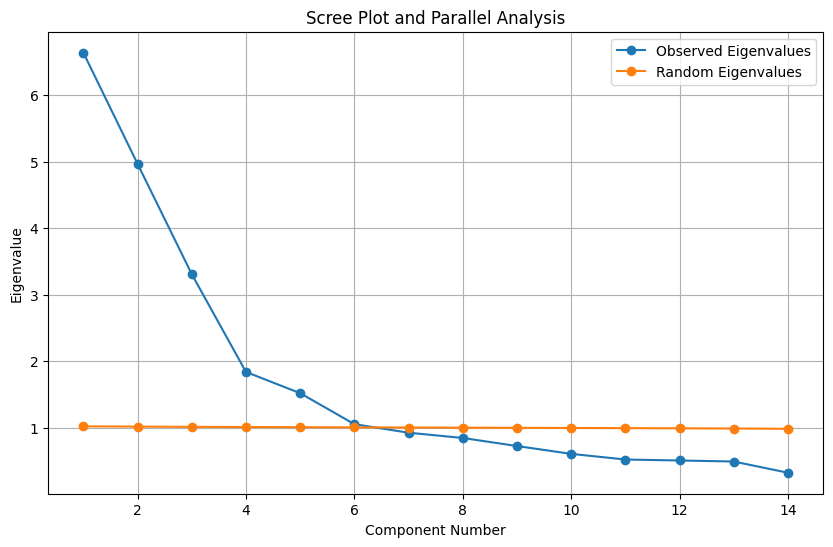

In [ ]:
# Scree Plot Vs Parallel Analysis
n_iterations = 100
n_samples, n_variables = df[columns].shape
random_eigenvalues = np.zeros((n_iterations, n_variables))

for i in range(n_iterations):
    random_data = np.random.normal(size=(n_samples, n_variables))
    random_pca = PCA()
    random_pca.fit(random_data)
    random_eigenvalues[i, :] = random_pca.explained_variance_

mean_random_eigenvalues = random_eigenvalues.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_variables + 1), observed_eigenvalues, marker="o", label="Observed Eigenvalues")
plt.plot(range(1, n_variables + 1), mean_random_eigenvalues, marker="o", label="Random Eigenvalues")
plt.xlabel("Component Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot and Parallel Analysis")
plt.legend()
plt.grid(True)
plt.show()

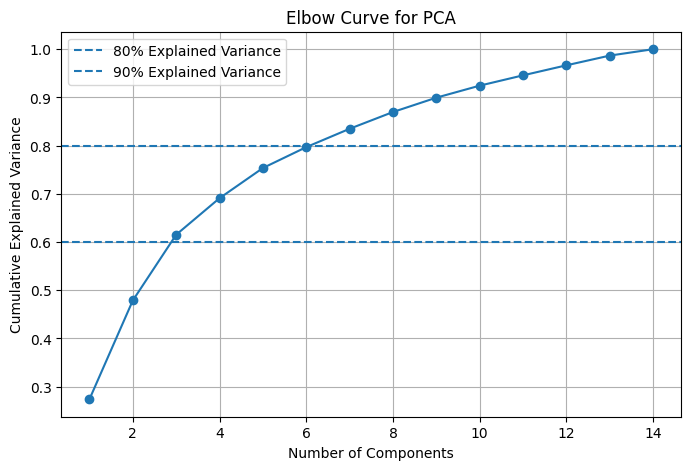

In [ ]:
# Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.60, linestyle="--", label="80% Explained Variance")
plt.axhline(y=0.80, linestyle="--", label="90% Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Elbow Curve for PCA")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# PCA Summary Table
pca_summary = pd.DataFrame({
    "Component": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Explained Variance": cumulative_variance
    })

print("\nPCA Summary:")
print(pca_summary)


PCA Summary:
    Component  Eigenvalue  Explained Variance Ratio  \
0           1    6.641364                  0.273871   
1           2    4.968374                  0.204882   
2           3    3.308689                  0.136441   
3           4    1.837064                  0.075755   
4           5    1.517465                  0.062576   
5           6    1.051211                  0.043349   
6           7    0.922635                  0.038047   
7           8    0.843475                  0.034782   
8           9    0.722226                  0.029783   
9          10    0.604300                  0.024920   
10         11    0.519101                  0.021406   
11         12    0.504573                  0.020807   
12         13    0.489029                  0.020166   
13         14    0.320471                  0.013215   

    Cumulative Explained Variance  
0                        0.273871  
1                        0.478753  
2                        0.615193  
3               

In [ ]:
#  Number of components needed to explain at least 60% of the variance
n_components_60 = np.argmax(cumulative_variance >= 0.60) + 1
print("\nNumber of components needed to explain at least 60% of the variance:", n_components_60)


Number of components needed to explain at least 60% of the variance: 3


Criteria:

* Kaiser: 6
* Elbow curve: 4
* Explained Variance (80%): 6
* Parallel Analysis: 6

**Decision:** 6

The final decision to retain six components was based on the majority of the criteria supporting this solution. Although the elbow method suggested a lower number of components, the remaining methods consistently indicated that six components provide a more adequate representation of the data.

Furthermore, selecting a slightly higher number of components allows for a greater proportion of variance to be captured, which can be beneficial in subsequent analyses. In particular, using principal components can help reduce the dimensionality of the dataset while preserving most of the information, thereby improving computational efficiency in logistic regression models and reducing the number of input variables without significant loss of explanatory power.

## 2.3 Analysing the Components

In [ ]:
# PCA with 6 components
pca = PCA(n_components=6)
pca_scores = pca.fit_transform(df[columns])

# Add component scores to the dataframe
df["PC1"] = pca_scores[:, 0]
df["PC2"] = pca_scores[:, 1]
df["PC3"] = pca_scores[:, 2]
df["PC4"] = pca_scores[:, 3]
df["PC5"] = pca_scores[:, 4]
df["PC6"] = pca_scores[:, 5]

In [ ]:
# Component loadings matrix
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    index=columns,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"]
)

print("Component Matrix / Factor Loadings")
print(loadings_df)

Component Matrix / Factor Loadings
                                        PC1       PC2       PC3       PC4  \
Seat comfort                       0.823846  0.803482 -0.069974  0.371189   
Departure/Arrival time convenient  0.551494  1.068964  0.067691 -0.583291   
Food and drink                     0.692476  1.070862 -0.083359  0.305979   
Gate location                      0.370821  0.869320 -0.070563 -0.502152   
Inflight wifi service              0.730824 -0.454202 -0.650147 -0.307357   
Inflight entertainment             0.829474  0.018007 -0.244118  0.850959   
Online support                     0.844857 -0.494455 -0.516525 -0.045569   
Ease of Online booking             1.006516 -0.555897 -0.048939 -0.265608   
On-board service                   0.618000 -0.272272  0.769028 -0.034137   
Leg room service                   0.547331 -0.204179  0.685672  0.073209   
Baggage handling                   0.515068 -0.211262  0.737076 -0.106382   
Checkin service                    0.4116

In [ ]:
for component in loadings_df.columns:
    print(f"\nLoadings for {component}")
    print(loadings_df[component].sort_values(key=abs, ascending=False))


Loadings for PC1
Ease of Online booking               1.006516
Online support                       0.844857
Online boarding                      0.844152
Inflight entertainment               0.829474
Seat comfort                         0.823846
Inflight wifi service                0.730824
Food and drink                       0.692476
On-board service                     0.618000
Departure/Arrival time convenient    0.551494
Leg room service                     0.547331
Baggage handling                     0.515068
Cleanliness                          0.513491
Checkin service                      0.411604
Gate location                        0.370821
Name: PC1, dtype: float64

Loadings for PC2
Food and drink                       1.070862
Departure/Arrival time convenient    1.068964
Gate location                        0.869320
Seat comfort                         0.803482
Ease of Online booking              -0.555897
Online boarding                     -0.520241
Online support    

In [ ]:
# Explained variance
explained_variance_df = pd.DataFrame({
    "Component": ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"],
    "Eigenvalue": pca.explained_variance_,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nExplained Variance")
print(explained_variance_df)


Explained Variance
  Component  Eigenvalue  Explained Variance Ratio  \
0       PC1    6.641364                  0.273871   
1       PC2    4.968374                  0.204882   
2       PC3    3.308689                  0.136441   
3       PC4    1.837064                  0.075755   
4       PC5    1.517465                  0.062576   
5       PC6    1.051211                  0.043349   

   Cumulative Explained Variance  
0                       0.273871  
1                       0.478753  
2                       0.615193  
3                       0.690949  
4                       0.753525  
5                       0.796874  


In [ ]:
# Communalities
communalities = np.sum(loadings**2, axis=1)

communalities_df = pd.DataFrame({
    "Variable": columns,
    "Communality": communalities
})

print("\nCommunalities")
print(communalities_df)


Communalities
                             Variable  Communality
0                        Seat comfort     1.562673
1   Departure/Arrival time convenient     1.931656
2                      Food and drink     1.752890
3                       Gate location     1.169909
4               Inflight wifi service     1.273017
5              Inflight entertainment     1.482601
6                      Online support     1.270368
7              Ease of Online booking     1.471949
8                    On-board service     1.133343
9                    Leg room service     1.642679
10                   Baggage handling     0.927185
11                    Checkin service     1.424869
12                        Cleanliness     0.953896
13                    Online boarding     1.327132


In general, the interpretation was based on the highest factor loadings, particularly those above approximately |0.50|.

#### Components
#### PC1 — Digital and Overall Service Experience
**Main contributing variables:**
- Ease of Online booking  
- Online support  
- Online boarding  
- Inflight entertainment  
- Seat comfort  
- Inflight wifi service  
- Food and drink  

#### PC2 — Airport Convenience and Basic Travel Comfort
**Main contributing variables:**
- Food and drink  
- Departure/Arrival time convenient  
- Gate location  
- Seat comfort  

#### PC3 — On-board Comfort and Operational Service
**Main contributing variables:**
- On-board service  
- Cleanliness  
- Baggage handling  
- Leg room service  

#### PC4 — Entertainment versus Travel Convenience
**Main contributing variables:**
- Inflight entertainment  
- Departure/Arrival time convenient  
- Gate location  

#### PC5 — Check-in Service
**Main contributing variables:**
- Checkin service  

#### PC6 — Leg Room Comfort
**Main contributing variables:**
- Leg room service

In [ ]:
df = df.rename(columns={
    "PC1": "Digital_Overall_Service_Experience",
    "PC2": "Airport_Convenience_Basic_Travel_Comfort",
    "PC3": "Onboard_Comfort_Operational_Service",
    "PC4": "Entertainment_vs_Travel_Convenience",
    "PC5": "Checkin_Service_Component",
    "PC6": "Leg_Room_Comfort"
})

# 3. Training and Test Dataset Split

## 3.1. Transformation of Non-Numeric Variables

In [ ]:
# View dataset general info (Type of Variables)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 31 columns):
 #   Column                                    Non-Null Count   Dtype   
---  ------                                    --------------   -----   
 0   satisfaction                              129880 non-null  object  
 1   Gender                                    129880 non-null  object  
 2   Customer Type                             129880 non-null  object  
 3   Age                                       129880 non-null  int64   
 4   Type of Travel                            129880 non-null  object  
 5   Class                                     129880 non-null  object  
 6   Flight Distance                           129880 non-null  int64   
 7   Seat comfort                              129880 non-null  int64   
 8   Departure/Arrival time convenient         129880 non-null  int64   
 9   Food and drink                            129880 non-null  int64   
 10  Gate loc

Transformations to be applied:

* **satisfaction (satisfied/dissatisfied)**: will be converted into a binary variable, where satisfied = 1 and dissatisfied = 0.
* **Gender (Male/Female)**: will be transformed into a binary variable (0/1).
* **Customer Type (Loyal/Disloyal)**: will be converted into a binary variable, where loyal customers = 1 and disloyal customers = 0.
Type of Travel (Personal Travel/Business Travel): will be transformed into a binary variable (0/1).
* **Class (Business/Economy)**:  - Class: convert to a binary variable, where Business = 1 and Eco = 0.
* **Departure Delay Category**: this variable was created solely for exploratory data analysis in order to better understand the relationship between delays and customer satisfaction. Since it represents a categorized version of an existing continuous variable, it does not provide additional information for predictive modeling and will therefore not be included in the final models.
* **Arrival Delay Category**: similarly, this variable was used only for exploratory purposes. As it is derived from the continuous delay variable, it will not be considered in the predictive models to avoid redundancy and potential multicollinearity.

In [ ]:
# =========================================
# Convert Binary Categorical Variables into Numerical Format
# =========================================

# Binary variables
df["satisfaction"] = df["satisfaction"].map({"satisfied": 1,"dissatisfied": 0})

df["Gender"] = df["Gender"].map({"Female": 1,"Male": 0})

df["Customer Type"] = df["Customer Type"].map({"Loyal Customer": 1,"disloyal Customer": 0,"Disloyal Customer": 0})

df["Type of Travel"] = df["Type of Travel"].map({"Business travel": 1,"Personal Travel": 0})

df["Class"] = df["Class"].map({"Business": 1,"Eco": 0})

# Remove categorical delay variables from the dataset

df = df.drop(["Departure Delay Category","Arrival Delay Category"], axis=1)


## 3.2. Training and Test Dataset Split

Two initial datasets will be created for testing purposes: one based on the original variables, and another including the variables derived from PCA while excluding the original variables used to generate those components.

In [ ]:
# =========================================
# Variables to keep in both datasets
# =========================================

base_variables = [
    "Gender",
    "Customer Type",
    "Age",
    "Type of Travel",
    "Class",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

service_variables = [
    "Seat comfort",
    "Departure/Arrival time convenient",
    "Food and drink",
    "Gate location",
    "Inflight wifi service",
    "Inflight entertainment",
    "Online support",
    "Ease of Online booking",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
    "Online boarding"
]

pca_variables = [
    "Digital_Overall_Service_Experience",
    "Airport_Convenience_Basic_Travel_Comfort",
    "Onboard_Comfort_Operational_Service",
    "Entertainment_vs_Travel_Convenience",
    "Checkin_Service_Component",
    "Leg_Room_Comfort"
]

# =========================================
# Baseline dataset
# Base variables + original service variables
# =========================================

X_base = df[base_variables + service_variables].copy()
y_base = df["satisfaction"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_base,
    y_base,
    test_size=0.20,
    random_state=42,
    stratify=y_base
)

# =========================================
# PCA dataset
# Base variables + PCA variables
# =========================================

X_PCA = df[base_variables + pca_variables].copy()
y_PCA = df["satisfaction"].copy()

X_PCA_train, X_PCA_test, y_PCA_train, y_PCA_test = train_test_split(
    X_PCA,
    y_PCA,
    test_size=0.20,
    random_state=42,
    stratify=y_PCA
)

# =========================================
# Check shapes
# =========================================

print("Baseline dataset")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nPCA dataset")
print("X_PCA_train shape:", X_PCA_train.shape)
print("X_PCA_test shape:", X_PCA_test.shape)
print("y_PCA_train shape:", y_PCA_train.shape)
print("y_PCA_test shape:", y_PCA_test.shape)

Baseline dataset
X_train shape: (103904, 22)
X_test shape: (25976, 22)
y_train shape: (103904,)
y_test shape: (25976,)

PCA dataset
X_PCA_train shape: (103904, 14)
X_PCA_test shape: (25976, 14)
y_PCA_train shape: (103904,)
y_PCA_test shape: (25976,)


# 4. Predictive Modelling

First, a baseline model will be estimated without including any newly created variables. This initial specification will allow the predictive performance of the original variables to be assessed on its own, providing a reference point for later comparisons. After that, additional models including the PCA components and the categorical delay variables may be tested in order to evaluate whether these new variables improve the model’s performance.

## 4.1. Decision Tree

### 4.1.1 - Baseline

In [ ]:
# Create and train the decision tree for the baseline dataset

tree_classifier_base = tree.DecisionTreeClassifier()
tree_classifier_base.fit(X_train, y_train)

DecisionTreeClassifier()

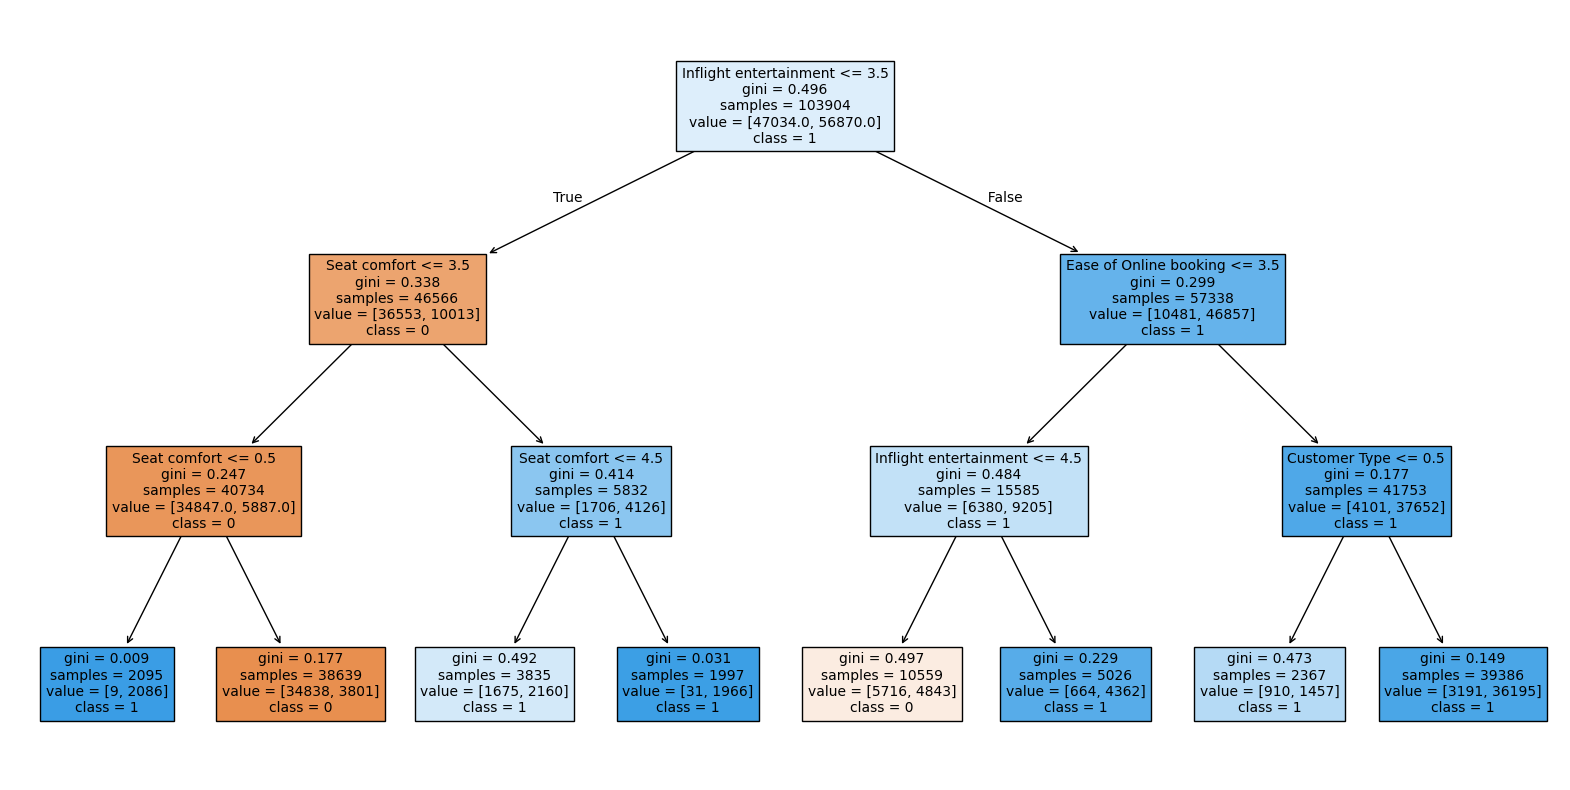

In [ ]:
# Create and train a decision tree with limited depth for the baseline dataset

tree_limited_depth_base = DecisionTreeClassifier(max_depth=3)
tree_limited_depth_base.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_limited_depth_base,
    filled=True,
    feature_names=X_train.columns,
    class_names=[str(cls) for cls in tree_limited_depth_base.classes_],
    fontsize=10
)
plt.show()

In [ ]:
# Predict the test sample using the baseline decision tree
y_predicted_base = tree_classifier_base.predict(X_test)
y_predicted_base

array([1, 1, 0, ..., 0, 0, 0])

In [ ]:
# Auxiliary function to print metrics. It uses scoring functions already available in sklearn
def print_metrics(real, predictions):
  print("f1 score:", f1_score(real, predictions, average='macro'))
  print("accuracy score:", accuracy_score(real, predictions))
  print("AUC score:", roc_auc_score(real, predictions))

# Print metrics for the baseline model
print("Baseline model metrics:")
print_metrics(y_test, y_predicted_base)

Baseline model metrics:
f1 score: 0.9385836900386622
accuracy score: 0.9391746227286726
AUC score: 0.9382942532713229


In [ ]:
# Print a short report with the results for the baseline model
print("Baseline model classification report:")
print(classification_report(y_test, y_predicted_base))

Baseline model classification report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     11759
           1       0.94      0.95      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



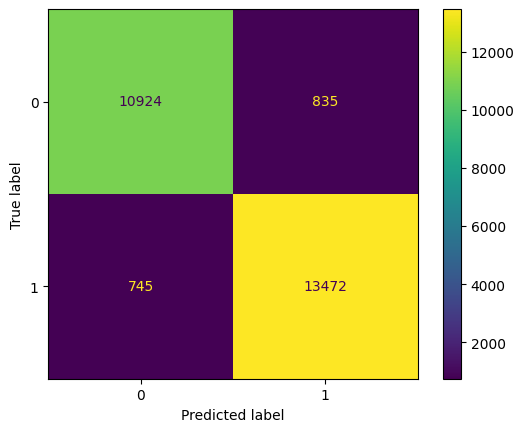

In [ ]:
# Plot the confusion matrix for the baseline model
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted_base)
plt.show()

### 4.1.2. PCA

In [ ]:
# Create and train the decision tree for the PCA dataset

tree_classifier_pca = tree.DecisionTreeClassifier()
tree_classifier_pca.fit(X_PCA_train, y_PCA_train)

DecisionTreeClassifier()

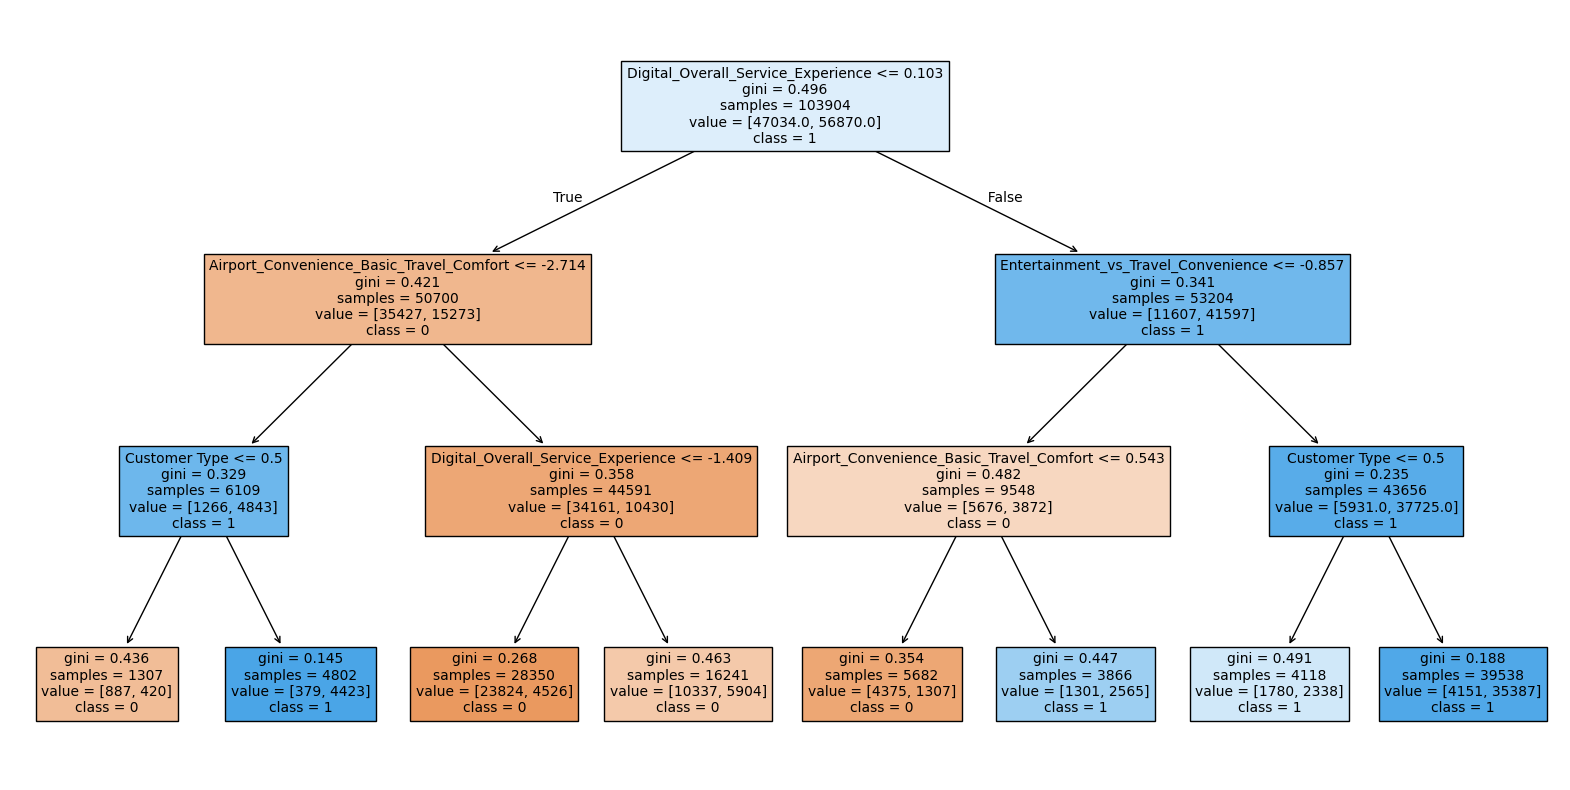

In [ ]:
# Create and train a decision tree with limited depth for the PCA dataset

tree_limited_depth_pca = DecisionTreeClassifier(max_depth=3)
tree_limited_depth_pca.fit(X_PCA_train, y_PCA_train)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_limited_depth_pca,
    filled=True,
    feature_names=X_PCA_train.columns,
    class_names=[str(cls) for cls in tree_limited_depth_pca.classes_],
    fontsize=10
)
plt.show()

In [ ]:
# Predict the test sample using the PCA decision tree
y_predicted_pca = tree_classifier_pca.predict(X_PCA_test)
y_predicted_pca

array([1, 1, 0, ..., 0, 0, 0])

In [ ]:
# Print metrics for the PCA model
print("PCA model metrics:")
print_metrics(y_PCA_test, y_predicted_pca)

PCA model metrics:
f1 score: 0.8864091650360062
accuracy score: 0.887434554973822
AUC score: 0.8863807753118847


In [ ]:
# Print a short report with the results for the PCA model
print("PCA model classification report:")
print(classification_report(y_PCA_test, y_predicted_pca))

PCA model classification report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     11759
           1       0.90      0.90      0.90     14217

    accuracy                           0.89     25976
   macro avg       0.89      0.89      0.89     25976
weighted avg       0.89      0.89      0.89     25976



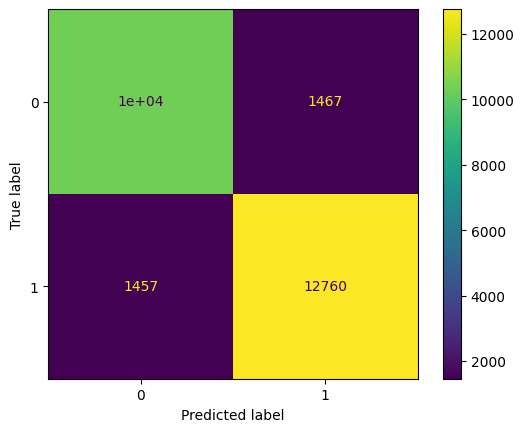

In [ ]:
# Plot the confusion matrix for the PCA model
ConfusionMatrixDisplay.from_predictions(y_PCA_test, y_predicted_pca)
plt.show()

The results obtained are strong for both models, indicating good predictive performance in both cases. However, the model using PCA consistently shows slightly lower performance, with metrics approximately 2–3% lower on average compared to the baseline model.

This reduction is expected, as PCA transforms the original variables into a smaller set of components, which inevitably leads to some loss of information. Additionally, the use of PCA reduces the interpretability of the model, since the components are linear combinations of the original variables and do not have a direct, intuitive meaning.

Nevertheless, PCA remains a valuable technique, as it allows for dimensionality reduction, simplifies the structure of the data, and helps to identify underlying relationships between variables.

## 4.2. Results Optimization

In this section, we will explore other classification models, such as BaggingClassifier, GradientBoostingClassifier, XGBClassifier, and Random Forests.

### 4.2.1. Bagging Model

In [ ]:
# Initialize the base classifier for the baseline dataset
base_cls_base = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging model for the baseline dataset
bagging_cls_base = BaggingClassifier(
    estimator=base_cls_base,
    n_estimators=10,
    random_state=42
)

# Train the Bagging model
bagging_cls_base.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  random_state=42)

In [ ]:
# Make predictions on the test set for the baseline model
y_predicted_bagging_base = bagging_cls_base.predict(X_test)

# Print metrics for the test dataset
print("Baseline Bagging model metrics:")
print_metrics(y_test, y_predicted_bagging_base)

Baseline Bagging model metrics:
f1 score: 0.9524061823181698
accuracy score: 0.9527255928549431
AUC score: 0.9535114619920337


In [ ]:
print("Baseline Bagging model classification report:")
print(classification_report(y_test, y_predicted_bagging_base))

Baseline Bagging model classification report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     11759
           1       0.97      0.95      0.96     14217

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



### 4.2.2. Boosting Model

The Boosting algorithm trains models sequentially in order to correct errors and improve the accuracy of the final model. It is used to reduce bias and variance, resulting in more accurate and robust predictions.

#### 4.2.2.1. GradientBoostingClassifier

#### 4.2.2.2. XGBClassifier

The XGBClassifier is an implementation of the XGBoost algorithm for classification problems, based on the construction of multiple decision trees. It builds these trees sequentially, so that each new tree attempts to correct the errors made by the previous one.

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# Baseline model
xgb_base = XGBClassifier()
xgb_base.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Classify the samples in the test dataset for the baseline model
y_predicted_xgb_base = xgb_base.predict(X_test)

# Print metrics for the test dataset
print("Baseline XGBoost model metrics:")
print_metrics(y_test, y_predicted_xgb_base)

Baseline XGBoost model metrics:
f1 score: 0.9589878995683802
accuracy score: 0.9593085925469664
AUC score: 0.9595327404396745


In [ ]:
print("Baseline XGBoost model classification report:")
print(classification_report(y_test, y_predicted_xgb_base))

Baseline XGBoost model classification report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     11759
           1       0.97      0.96      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



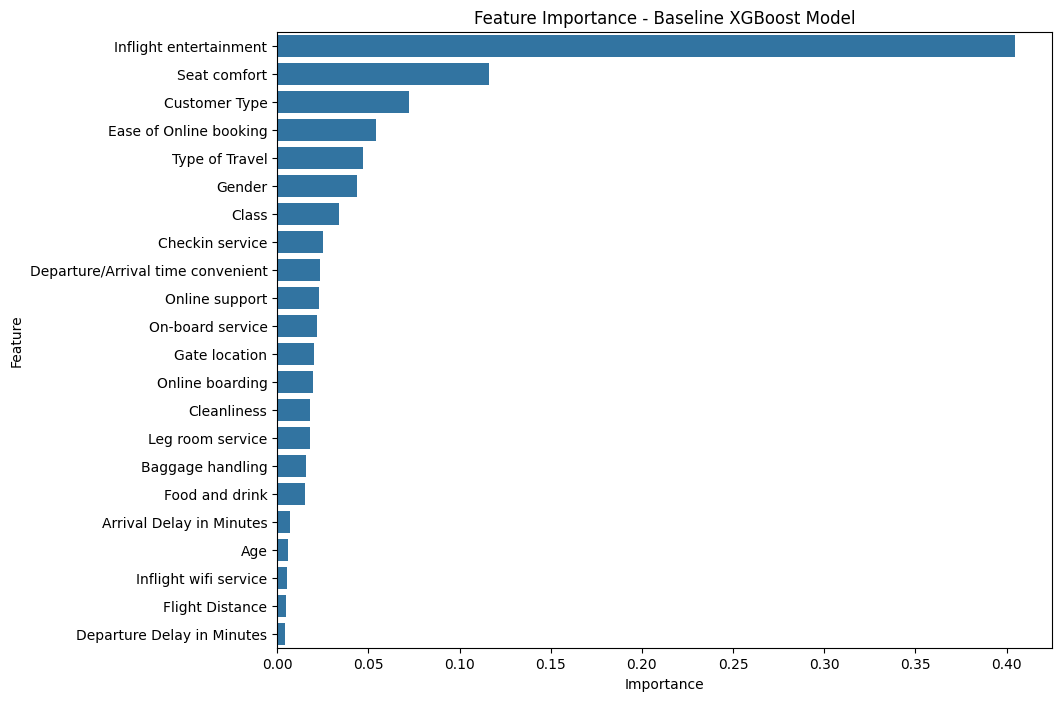

In [ ]:
# Create a dataframe with the feature importance values and their names for the baseline model
feature_importance_df_base = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_base.feature_importances_
})

# Sort the dataframe
feature_importance_df_base = feature_importance_df_base.sort_values(by="Importance", ascending=False)

# Plot the chart
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df_base, y="Feature", x="Importance")
plt.title("Feature Importance - Baseline XGBoost Model")
plt.show()

In [ ]:


# Create SHAP explainer
explainer = shap.Explainer(xgb_base, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Mean absolute SHAP value = overall importance
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values.values).mean(axis=0),
    "Mean_SHAP": shap_values.values.mean(axis=0)
})

# Direction based on average SHAP value
importance_df["Direction"] = importance_df["Mean_SHAP"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Sort by importance
importance_df = importance_df.sort_values(by="Mean_Absolute_SHAP", ascending=False)

print(importance_df)

100%|===================| 25960/25976 [02:48<00:00]       

                              Feature  Mean_Absolute_SHAP  Mean_SHAP Direction
8                        Seat comfort            2.102803   0.070071  Positive
1                       Customer Type            1.208341   0.150336  Positive
3                      Type of Travel            0.920281   0.109333  Positive
13             Inflight entertainment            0.857143   0.016916  Positive
0                              Gender            0.654707  -0.069011  Negative
11                      Gate location            0.524335   0.073464  Positive
9   Departure/Arrival time convenient            0.423828   0.038877  Positive
20                        Cleanliness            0.406944  -0.036669  Negative
18                   Baggage handling            0.394279   0.080547  Positive
15             Ease of Online booking            0.367645   0.090887  Positive
19                    Checkin service            0.330756   0.026761  Positive
14                     Online support            0.3

In [ ]:
positive_impact_xgb = importance_df[importance_df["Direction"] == "Positive"] \
    .sort_values(by="Mean_Absolute_SHAP", ascending=False)

print("Most important positive variables:")
print(positive_impact_xgb)

Most important positive variables:
                              Feature  Mean_Absolute_SHAP  Mean_SHAP Direction
8                        Seat comfort            2.102803   0.070071  Positive
1                       Customer Type            1.208341   0.150336  Positive
3                      Type of Travel            0.920281   0.109333  Positive
13             Inflight entertainment            0.857143   0.016916  Positive
11                      Gate location            0.524335   0.073464  Positive
9   Departure/Arrival time convenient            0.423828   0.038877  Positive
18                   Baggage handling            0.394279   0.080547  Positive
15             Ease of Online booking            0.367645   0.090887  Positive
19                    Checkin service            0.330756   0.026761  Positive
17                   Leg room service            0.274038   0.026912  Positive
21                    Online boarding            0.256931   0.019900  Positive
16               

In [ ]:
negative_impact_xgb = importance_df[importance_df["Direction"] == "Negative"] \
    .sort_values(by="Mean_Absolute_SHAP", ascending=False)

print("Most important negative variables:")
print(negative_impact_xgb)

Most important negative variables:
                       Feature  Mean_Absolute_SHAP  Mean_SHAP Direction
0                       Gender            0.654707  -0.069011  Negative
20                 Cleanliness            0.406944  -0.036669  Negative
14              Online support            0.318838  -0.007904  Negative
4                        Class            0.234104  -0.033956  Negative
6   Departure Delay in Minutes            0.103925  -0.010950  Negative


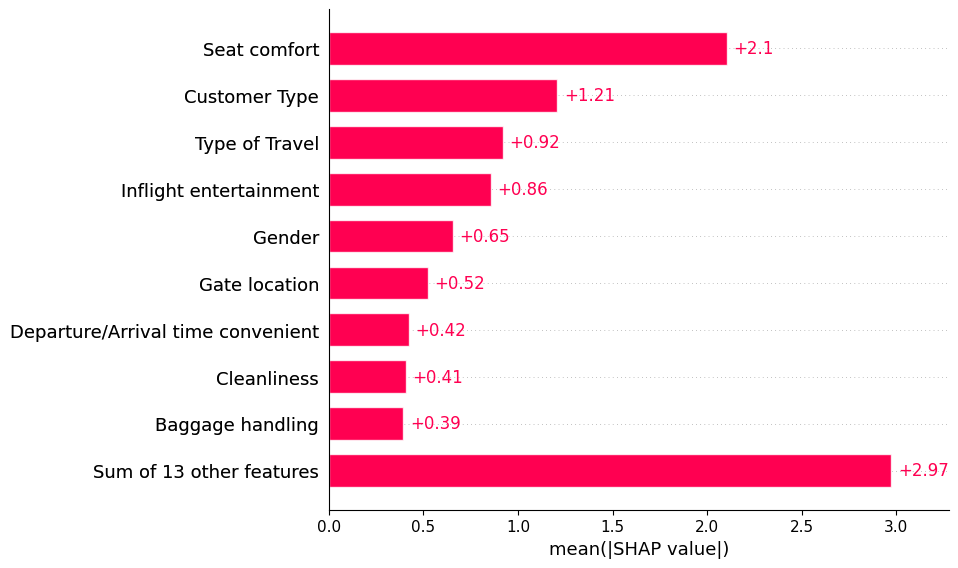

In [ ]:
shap.plots.bar(shap_values)

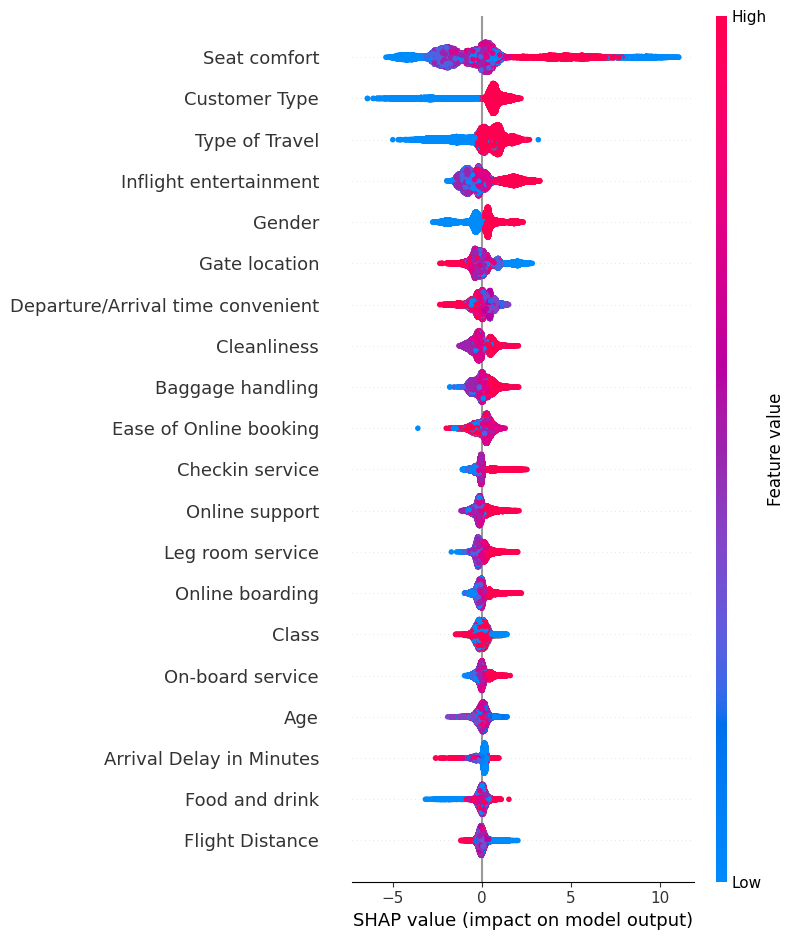

In [ ]:
shap.summary_plot(shap_values.values, X_test)

The XGBoost Baseline model, identified as the winning model, confirms that customer satisfaction is primarily explained by variables related to the quality of the service experience. The SHAP analysis clearly shows that Seat comfort is by far the most influential variable, followed by Customer Type and Type of Travel. This suggests that passenger comfort, customer loyalty, and the context of the trip are the main determinants of satisfaction. Other variables with a relevant positive contribution include Inflight entertainment, Gate location, Departure/Arrival time convenient, Baggage handling, and Ease of Online booking, reinforcing the idea that both the onboard experience and operational convenience play an important role in the overall evaluation of the service.

On the other hand, the analysis also shows that some variables tend to contribute negatively to satisfaction, although with a lower average impact than the strongest positive predictors. These include Gender, Cleanliness, Online support, Class, and Departure Delay in Minutes. In the case of delays, the result is consistent with expectations, as longer delays tend to reduce satisfaction. The remaining variables should be interpreted with caution, since the negative SHAP values depend on how the variables are encoded and how they interact with other features. Overall, the results confirm that the winning model is strongly driven by perceived service quality and customer experience, with Seat comfort emerging as the most decisive factor.

### 4.2.3. Random Forest

A Random Forest model is an algorithm that builds a collection of decision trees during training, producing predictions based on the aggregation of individual trees. Its purpose is to support automated and informed decision-making by classifying input data into predefined categories based on patterns learned during the training process.

#### 4.2.3.1 Baseline

In [ ]:
# Create and train the Random Forest model for the baseline dataset
rfc_model_base = RandomForestClassifier(random_state=0)
rfc_model_base.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Make predictions and evaluate the baseline Random Forest model
y_predicted_rf_base = rfc_model_base.predict(X_test)

# Print metrics for the test dataset
print("Baseline Random Forest model metrics:")
print_metrics(y_test, y_predicted_rf_base)

Baseline Random Forest model metrics:
f1 score: 0.9584307879948023
accuracy score: 0.9587311364336311
AUC score: 0.9592772069610264


#### 4.2.3.2 PCA

In [ ]:
# Create and train the Random Forest model for the PCA dataset
rfc_model_pca = RandomForestClassifier(random_state=0)
rfc_model_pca.fit(X_PCA_train, y_PCA_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Make predictions and evaluate the PCA Random Forest model
y_predicted_rf_pca = rfc_model_pca.predict(X_PCA_test)

# Print metrics for the test dataset
print("PCA Random Forest model metrics:")
print_metrics(y_PCA_test, y_predicted_rf_pca)

PCA Random Forest model metrics:
f1 score: 0.9251530251485303
accuracy score: 0.925816137973514
AUC score: 0.9251936754986997


## 4.3. Grid Search

Modeling algorithms may have a large number of parameters, such as the depth of a tree. At the outset, it is not possible to know which parameter values will lead to the best model performance.

In order to improve the evaluation metrics of our classification models, particularly the F1-score, we will use the Grid Search technique to tune the hyperparameters of each model.

Grid Search is an exhaustive method that tests predefined combinations of hyperparameters. It is useful when the hyperparameter space is not too large, since the computational time increases rapidly with the number of combinations to be tested.

### 4.3.1. GridSearchCV - Decision Tree

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

In [ ]:
# Instantiate the Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)

In [ ]:
# Configure GridSearchCV
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)

#### 4.3.1.1 Baseline


In [ ]:
# Training GridSearchCV model for the baseline dataset
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10, 15],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_macro', verbose=1)

In [ ]:
# Best parameters for the baseline model
print("Best parameters (baseline):", grid_search.best_params_)

Best parameters (baseline): {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [ ]:
# Predictions and metrics for the baseline model
y_predicted_grid_base = grid_search.predict(X_test)
print("Baseline GridSearchCV model metrics:")
print_metrics(y_test, y_predicted_grid_base)

Baseline GridSearchCV model metrics:
f1 score: 0.9453647994924939
accuracy score: 0.9457961194949184
AUC score: 0.9458577499416893


#### 4.3.1.2 PCA

In [ ]:
# Training GridSearchCV model for the PCA dataset
grid_search.fit(X_PCA_train, y_PCA_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10, 15],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_macro', verbose=1)

In [ ]:
# Best parameters for the PCA model
print("Best parameters (PCA):", grid_search.best_params_)

Best parameters (PCA): {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [ ]:
# Predictions and metrics for the PCA model
y_predicted_grid_pca = grid_search.predict(X_PCA_test)
print("PCA GridSearchCV model metrics:")
print_metrics(y_PCA_test, y_predicted_grid_pca)

PCA GridSearchCV model metrics:
f1 score: 0.8989010046278156
accuracy score: 0.8997151216507545
AUC score: 0.8992758711369543


### 4.3.2. GridSearchCV - Bagging


In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid_bagging = {
    "estimator__max_depth": [None, 3, 5, 7],
    "estimator__min_samples_leaf": [1, 2, 4],
    "max_samples": [0.5, 0.75, 1.0],
    "max_features": [0.5, 0.75, 1.0]
}

# Initialize the base classifier
base_cls_bagging = DecisionTreeClassifier(random_state=42)

# Initialize the Bagging classifier
bagging_cls_baseline = BaggingClassifier(
    estimator=base_cls_bagging,
    random_state=42
)

# Configure GridSearchCV
grid_search_bagging_baseline = GridSearchCV(
    estimator=bagging_cls_baseline,
    param_grid=param_grid_bagging,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Train the model with GridSearchCV
grid_search_bagging_baseline.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [None, 3, 5, 7],
                         'estimator__min_samples_leaf': [1, 2, 4],
                         'max_features': [0.5, 0.75, 1.0],
                         'max_samples': [0.5, 0.75, 1.0]},
             scoring='f1_macro')

In [ ]:
# Get the best estimator
best_bagging_cls_baseline = grid_search_bagging_baseline.best_estimator_

In [ ]:
# Predict using the best estimator
y_predicted = best_bagging_cls_baseline.predict(X_test)

In [ ]:
# Better parameters
print("Melhores parâmetros:", grid_search.best_params_)

Melhores parâmetros: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [ ]:
# Printing metrics
print_metrics(y_test, y_predicted)

f1 score: 0.9524061823181698
accuracy score: 0.9527255928549431
AUC score: 0.9535114619920337


### 4.3.3. GridSearchCV - Gradient Boosting


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Pipeline
gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("gb", GradientBoostingClassifier(random_state=0))
])

# Parameter grid
param_grid_gb = {
    "gb__n_estimators": [50, 100, 150],
    "gb__learning_rate": [0.05, 0.1],
    "gb__max_depth": [3, 5]
}

# GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Train model
grid_search_gb.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='most_frequent')),
                                       ('gb',
                                        GradientBoostingClassifier(random_state=0))]),
             n_jobs=-1,
             param_grid={'gb__learning_rate': [0.05, 0.1],
                         'gb__max_depth': [3, 5],
                         'gb__n_estimators': [50, 100, 150]},
             scoring='f1_macro', verbose=1)

In [ ]:
# Get the best estimator for the Gradient Boosting model
best_model_gb = grid_search_gb.best_estimator_

In [ ]:
# Predict using the best estimator
y_predicted_gb = best_model_gb.predict(X_test)

In [ ]:
# Printing the metrics
print_metrics(y_test, y_predicted)

f1 score: 0.9524061823181698
accuracy score: 0.9527255928549431
AUC score: 0.9535114619920337


### 4.3.4. GridSearchCV - XGBClassifier


In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
}

In [ ]:
# Instantiate the model
xgb_gs = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Configure GridSearchCV
grid_search = GridSearchCV(estimator=xgb_gs, param_grid=param_grid, scoring='f1_macro', cv=3, verbose=1)

In [ ]:
# Training GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:23:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:23:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:23:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:23:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'max_depth': [3, 4, 5, 6],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='f1_macro', verbose=1)

In [ ]:
# Best parameters
print("Best parameters:", grid_search.best_params_)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 6, 'subsample': 1.0}


In [ ]:
# Print Metrics
print_metrics(y_test, y_predicted)

f1 score: 0.9524061823181698
accuracy score: 0.9527255928549431
AUC score: 0.9535114619920337


### 4.3.5. GridSearchCV - Random Forest

In [ ]:
# Define the parameters and their respective ranges to be tested
param_grid_random_forest = {
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [2,3,4],
    'criterion' :['gini', 'entropy']
}

# Define an instance of the classifier
classifier_random_forest = RandomForestClassifier()

# Define an instance of grid search
gs_random_forest = GridSearchCV(estimator=classifier_random_forest, param_grid=param_grid_random_forest, cv=5)

# Train the model with GridSearchCV
gs_random_forest.fit(X_train, y_train)

# View the parameters from the analysis that produced the best results
gs_random_forest.best_params_

{'criterion': 'gini', 'max_depth': 4, 'max_features': 'log2'}

In [ ]:
# Classify the test sample
y_predicted = gs_random_forest.predict(X_test)

In [ ]:
# Print metrics - note that this method uses cross-validation, which generally implies a decrease in the metric values
print_metrics(y_test, y_predicted)

f1 score: 0.8775677323284262
accuracy score: 0.8787727132737911
AUC score: 0.8772400198607825


## 4.4. Neural Network

 ### 4.4.1. Baseline

In [ ]:
# Neural network model for the baseline dataset
nn_model_base = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

In [ ]:
# Train the model
nn_model_base.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500,
                               random_state=42))])

In [ ]:
# Predictions
y_predicted_nn_base = nn_model_base.predict(X_test)

In [ ]:
# Metrics
print("Baseline Neural Network model metrics:")
print_metrics(y_test, y_predicted_nn_base)

Baseline Neural Network model metrics:
f1 score: 0.9503082268148256
accuracy score: 0.9506467508469356
AUC score: 0.9513550260945983


In [ ]:
# Classification report
print("Baseline Neural Network classification report:")
print(classification_report(y_test, y_predicted_nn_base))

Baseline Neural Network classification report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     11759
           1       0.97      0.94      0.95     14217

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



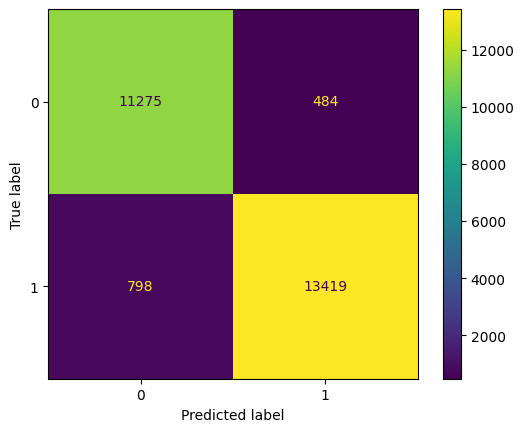

In [ ]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted_nn_base)
plt.show()

### 4.4.2. Tunning

Fitting 5 folds for each of 56 candidates, totalling 280 fits
Best parameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__solver': 'adam'}
Neural Network GridSearchCV model metrics:
f1 score: 0.9537784157905104
accuracy score: 0.9541499846011703
AUC score: 0.954209901424474
Neural Network GridSearchCV classification report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     11759
           1       0.96      0.95      0.96     14217

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



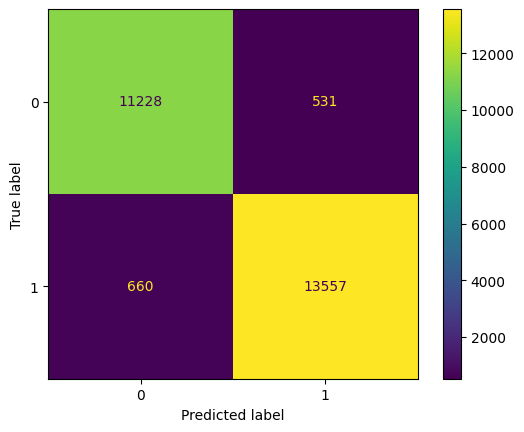

In [ ]:
# More demanding Neural Network Tuning Pipeline
nn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        random_state=42,
        max_iter=800,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.1
    ))
])

# More demanding hyperparameter grid
param_grid_nn = {
    "mlp__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (32, 16),
        (64, 32),
        (128, 64),
        (64, 32, 16)
    ],
    "mlp__activation": ["relu", "tanh"],
    "mlp__solver": ["adam"],
    "mlp__alpha": [0.0001, 0.001, 0.01, 0.1]
}

# GridSearchCV
grid_search_nn = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid_nn,
    scoring="f1_macro",
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Train the model
grid_search_nn.fit(X_train, y_train)

# Best parameters
print("Best parameters:", grid_search_nn.best_params_)

# Predictions on the test set
y_predicted_nn_grid = grid_search_nn.predict(X_test)

# Main metrics
print("Neural Network GridSearchCV model metrics:")
print_metrics(y_test, y_predicted_nn_grid)

# Full classification report
print("Neural Network GridSearchCV classification report:")
print(classification_report(y_test, y_predicted_nn_grid))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted_nn_grid)
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# Predicted probabilities for class 1 (satisfied)
y_prob_nn = grid_search_nn.predict_proba(X_test)[:, 1]

# Permutation importance
perm_importance = permutation_importance(
    grid_search_nn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

# Approximate direction using correlation with predicted probability
direction_list = []

for col in X_test.columns:
    valid = pd.DataFrame({
        "x": X_test[col],
        "y_prob": y_prob_nn
    }).dropna()

    corr = valid["x"].corr(valid["y_prob"])

    if corr > 0:
        direction = "Positive"
    elif corr < 0:
        direction = "Negative"
    else:
        direction = "Neutral"

    direction_list.append(corr)

importance_df["Correlation_with_Predicted_Satisfaction"] = direction_list
importance_df["Direction"] = importance_df["Correlation_with_Predicted_Satisfaction"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

                              Feature  Importance  \
8                        Seat comfort    0.161972   
3                      Type of Travel    0.112761   
1                       Customer Type    0.093076   
0                              Gender    0.065851   
18                   Baggage handling    0.040581   
13             Inflight entertainment    0.032116   
20                        Cleanliness    0.031401   
15             Ease of Online booking    0.019681   
14                     Online support    0.019063   
19                    Checkin service    0.017310   
11                      Gate location    0.017076   
10                     Food and drink    0.009060   
9   Departure/Arrival time convenient    0.006172   
17                   Leg room service    0.005709   
4                               Class    0.005110   
2                                 Age    0.004840   
16                   On-board service    0.003328   
21                    Online boarding    0.002

In [ ]:
# Predicted probabilities for class 1 (satisfied)
y_prob_nn = grid_search_nn.predict_proba(X_test)[:, 1]

# Permutation importance
perm_importance = permutation_importance(
    grid_search_nn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

# Approximate direction using correlation with predicted probability
correlations = []

for col in X_test.columns:
    valid = pd.DataFrame({
        "x": X_test[col],
        "y_prob": y_prob_nn
    }).dropna()

    corr = valid["x"].corr(valid["y_prob"])
    correlations.append(corr)

importance_df["Correlation_with_Predicted_Satisfaction"] = correlations
importance_df["Direction"] = importance_df["Correlation_with_Predicted_Satisfaction"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

                              Feature  Importance  \
8                        Seat comfort    0.161972   
3                      Type of Travel    0.112761   
1                       Customer Type    0.093076   
0                              Gender    0.065851   
18                   Baggage handling    0.040581   
13             Inflight entertainment    0.032116   
20                        Cleanliness    0.031401   
15             Ease of Online booking    0.019681   
14                     Online support    0.019063   
19                    Checkin service    0.017310   
11                      Gate location    0.017076   
10                     Food and drink    0.009060   
9   Departure/Arrival time convenient    0.006172   
17                   Leg room service    0.005709   
4                               Class    0.005110   
2                                 Age    0.004840   
16                   On-board service    0.003328   
21                    Online boarding    0.002

In [ ]:
positive_impact = importance_df[importance_df["Direction"] == "Positive"] \
    .sort_values(by="Importance", ascending=False)

print("Most important positive variables:")
print(positive_impact)

Most important positive variables:
                   Feature  Importance  \
8             Seat comfort    0.161972   
3           Type of Travel    0.112761   
1            Customer Type    0.093076   
0                   Gender    0.065851   
18        Baggage handling    0.040581   
13  Inflight entertainment    0.032116   
20             Cleanliness    0.031401   
15  Ease of Online booking    0.019681   
14          Online support    0.019063   
19         Checkin service    0.017310   
10          Food and drink    0.009060   
17        Leg room service    0.005709   
4                    Class    0.005110   
2                      Age    0.004840   
16        On-board service    0.003328   
21         Online boarding    0.002942   
12   Inflight wifi service    0.001371   

    Correlation_with_Predicted_Satisfaction Direction  
8                                  0.255769  Positive  
3                                  0.113319  Positive  
1                                  0.304

In [ ]:
negative_impact = importance_df[importance_df["Direction"] == "Negative"] \
    .sort_values(by="Importance", ascending=False)

print("Most important negative variables:")
print(negative_impact)

Most important negative variables:
                              Feature  Importance  \
11                      Gate location    0.017076   
9   Departure/Arrival time convenient    0.006172   
7            Arrival Delay in Minutes    0.002388   
5                     Flight Distance    0.001933   
6          Departure Delay in Minutes    0.001485   

    Correlation_with_Predicted_Satisfaction Direction  
11                                -0.020551  Negative  
9                                 -0.020397  Negative  
7                                 -0.087972  Negative  
5                                 -0.054825  Negative  
6                                 -0.080182  Negative  


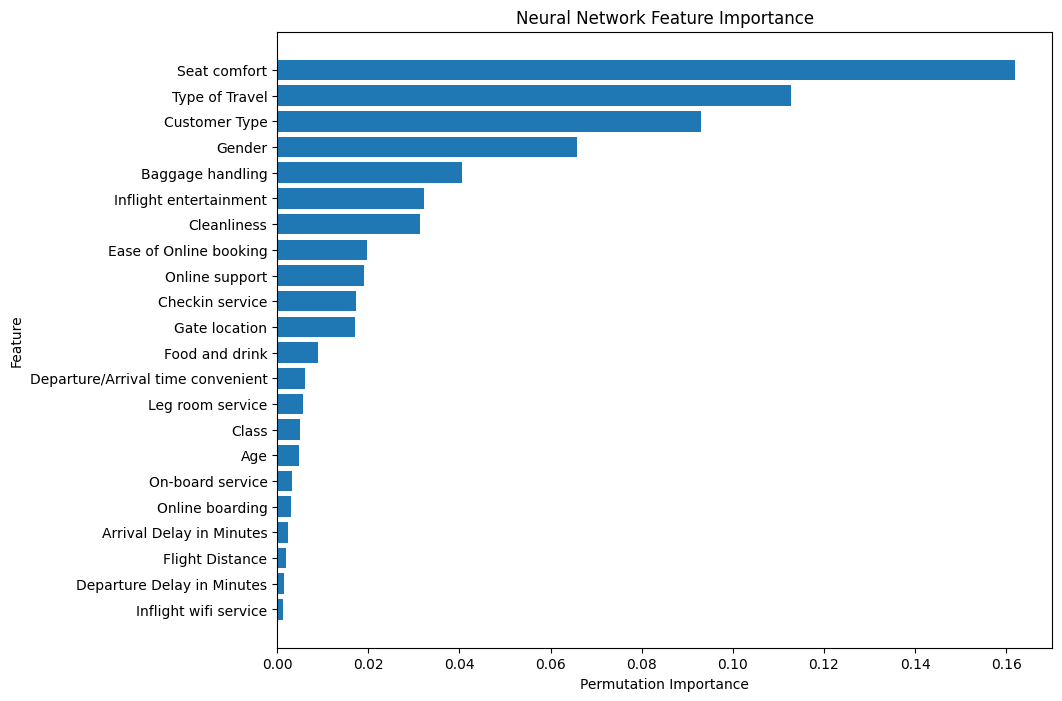

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Neural Network Feature Importance")
plt.gca().invert_yaxis()
plt.show()

The variables with the strongest positive impact on predicted satisfaction are Seat comfort, Type of Travel, and Customer Type. Among them, Seat comfort stands out clearly as the most influential predictor in the neural network, suggesting that passengers’ physical comfort is one of the main drivers of satisfaction. Type of Travel is the second most important variable, indicating that the purpose of the trip is strongly associated with how customers evaluate their experience. Customer Type also plays a major role, which suggests that loyalty status is highly relevant in explaining satisfaction, with the positive relationship indicating that loyal customers are more likely to be predicted as satisfied.

Regarding the variables with the strongest negative impact, the most relevant are Gate location, Departure/Arrival time convenient, and Arrival Delay in Minutes. Although their importance is considerably lower than that of the main positive predictors, they still provide useful insight. Gate location appears as the most important negative variable, suggesting that worse evaluations of airport convenience may reduce the probability of customer satisfaction. Similarly, Departure/Arrival time convenient shows a slight negative relationship, indicating that less convenient scheduling is associated with lower predicted satisfaction. Finally, Arrival Delay in Minutes confirms that longer delays tend to reduce satisfaction, which is consistent with expectations, even if its relative importance in the model is more modest than that of the service-related variables.

The neural network analysis also identified Seat comfort, Customer Type, and Type of Travel as the most important positive drivers of satisfaction, which is strongly aligned with the findings from the XGBoost model. Additionally, both models highlight the importance of service-related variables such as Inflight entertainment, Baggage handling, Ease of Online booking, and Checkin service. This consistency suggests that, despite their structural differences, both models converge on the same key factors explaining customer satisfaction.

However, some differences emerge in the negative effects. In the neural network, the main negative contributors were Gate location, Departure/Arrival time convenient, and Arrival Delay in Minutes, whereas in the XGBoost model, variables such as Gender, Cleanliness, Online support, Class, and Departure Delay in Minutes appear more prominently. These differences are expected, as each model captures relationships in a different way and may emphasize distinct interactions between variables. Nevertheless, both models agree on the central insight: customer satisfaction is primarily explained by perceived service quality, travel convenience, and certain customer characteristics. Therefore, it can be concluded that the models are largely consistent in identifying the main drivers of satisfaction, even if they differ slightly in the interpretation of secondary effects.

# 5. Results

In [ ]:
import pandas as pd

# Create results table
results = pd.DataFrame({
    "Model": [
        "Decision Tree Baseline",
        "Decision Tree PCA",
        "Bagging Baseline",
        "XGBoost Baseline",
        "Random Forest Baseline",
        "Random Forest PCA",
        "GridSearch DT Baseline",
        "GridSearch DT PCA",
        "GridSearch Bagging Baseline",
        "GridSearch Gradient Boosting (PCA)",
        "GridSearch Random Forest",
        "Neural Network Baseline",
        "Neural Network Tuning"
    ],
    "F1 Score": [
        0.9386, 0.8864, 0.9524, 0.9590, 0.9584, 0.9252,
        0.9454, 0.8989, 0.9524, 0.8989, 0.8776, 0.9503, 0.9538
    ],
    "Accuracy": [
        0.9392, 0.8874, 0.9527, 0.9593, 0.9587, 0.9258,
        0.9458, 0.8997, 0.9527, 0.8997, 0.8788, 0.9506, 0.9541
    ],
    "AUC": [
        0.9383, 0.8864, 0.9535, 0.9595, 0.9593, 0.9252,
        0.9459, 0.8993, 0.9535, 0.8993, 0.8772, 0.9514, 0.9542
    ],
    "Precision class 0": [
        0.94, 0.88, 0.94, 0.95, "-", "-", "-", "-", "-", "-", "-", 0.93, 0.94
    ],
    "Recall class 0": [
        0.93, 0.88, 0.96, 0.96, "-", "-", "-", "-", "-", "-", "-", 0.96, 0.95
    ],
    "F1 class 0": [
        0.93, 0.88, 0.95, 0.96, "-", "-", "-", "-", "-", "-", "-", 0.95, 0.95
    ],
    "Precision class 1": [
        0.94, 0.90, 0.97, 0.97, "-", "-", "-", "-", "-", "-", "-", 0.97, 0.96
    ],
    "Recall class 1": [
        0.95, 0.90, 0.95, 0.96, "-", "-", "-", "-", "-", "-", "-", 0.94, 0.95
    ],
    "F1 class 1": [
        0.94, 0.90, 0.96, 0.96, "-", "-", "-", "-", "-", "-", "-", 0.95, 0.96
    ]
})

# Sort by best model
results = results.sort_values(by="F1 Score", ascending=False)

# Display
print(results)

                                 Model  F1 Score  Accuracy     AUC  \
3                     XGBoost Baseline    0.9590    0.9593  0.9595   
4               Random Forest Baseline    0.9584    0.9587  0.9593   
12               Neural Network Tuning    0.9538    0.9541  0.9542   
8          GridSearch Bagging Baseline    0.9524    0.9527  0.9535   
2                     Bagging Baseline    0.9524    0.9527  0.9535   
11             Neural Network Baseline    0.9503    0.9506  0.9514   
6               GridSearch DT Baseline    0.9454    0.9458  0.9459   
0               Decision Tree Baseline    0.9386    0.9392  0.9383   
5                    Random Forest PCA    0.9252    0.9258  0.9252   
9   GridSearch Gradient Boosting (PCA)    0.8989    0.8997  0.8993   
7                    GridSearch DT PCA    0.8989    0.8997  0.8993   
1                    Decision Tree PCA    0.8864    0.8874  0.8864   
10            GridSearch Random Forest    0.8776    0.8788  0.8772   

   Precision class 

The best-performing model was XGBoost using the baseline dataset, achieving the highest values across all three main metrics, with an F1 score of 0.9590, accuracy of 0.9593, and AUC of 0.9595. Random Forest on the baseline dataset performed almost identically, with only marginally lower values, confirming that tree-based ensemble methods were the most effective approaches for this problem.

A clear pattern can be observed when comparing baseline models with their PCA-based counterparts. In general, the PCA versions performed worse, with results typically 2 to 5 percentage points lower, depending on the model. This suggests that although PCA helped reduce dimensionality, it also led to some loss of predictive information. In this case, the original variables appear to preserve more useful detail for classification than the transformed components.

Comparing methods, ensemble models such as XGBoost, Random Forest, and Bagging consistently outperformed single Decision Trees. The Neural Network with tuning also produced very strong results and outperformed both the baseline neural network and the decision tree models, although it still remained slightly below XGBoost and Random Forest. This indicates that more flexible and complex models were better able to capture the relationships between the explanatory variables and customer satisfaction.
